<a href="https://colab.research.google.com/github/elenarieee/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [17]:
path_dark = "sample_data/dark.png"
path_bright = "sample_data/bright.png"
path_contrast = "sample_data/low_contrast.png"
path_blur = "sample_data/blurred.png"

Log Transform untuk Dark Image, Invers Log Transform untuk Bright Image

In [25]:
def log_transform(img):
    r = img.astype(np.float32)
    c = 255.0 / np.log(1 + 255.0)
    s = c * np.log(1 + r)
    return np.clip(s, 0, 255).astype(np.uint8)


def invers_log_transform(img):
    r = img.astype(np.float32)
    c = 255.0 / np.log(1 + 255.0)
    s = np.exp(r / c) - 1
    return np.clip(s, 0, 255).astype(np.uint8)


def cerahkan(img):
    return log_transform(img)


def gelapkan(img):
    return invers_log_transform(img)

Contrast Stretching untuk Low Contrast

In [26]:
def naikkan_kontras(img):
    r = img.astype(np.float32)
    r_min = r.min()
    r_max = r.max()
    s = (r - r_min) / (r_max - r_min) * 255.0
    return np.clip(s, 0, 255).astype(np.uint8)

Sharpening dengan Laplacian Filter untuk Blurred Image

In [27]:
def pertajam(img):
    laplacian = cv2.Laplacian(img, cv2.CV_64F)
    hasil = img.astype(np.float64) - laplacian
    return np.clip(hasil, 0, 255).astype(np.uint8)

In [30]:
def baca(path):
    bgr = cv2.imread(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

img_dark = baca(path_dark)
img_bright = baca(path_bright)
img_contrast = baca(path_contrast)
img_blur = baca(path_blur)

hasil_dark = cerahkan(img_dark)
hasil_bright = gelapkan(img_bright)
hasil_contrast = naikkan_kontras(img_contrast)
hasil_blur = pertajam(img_blur)

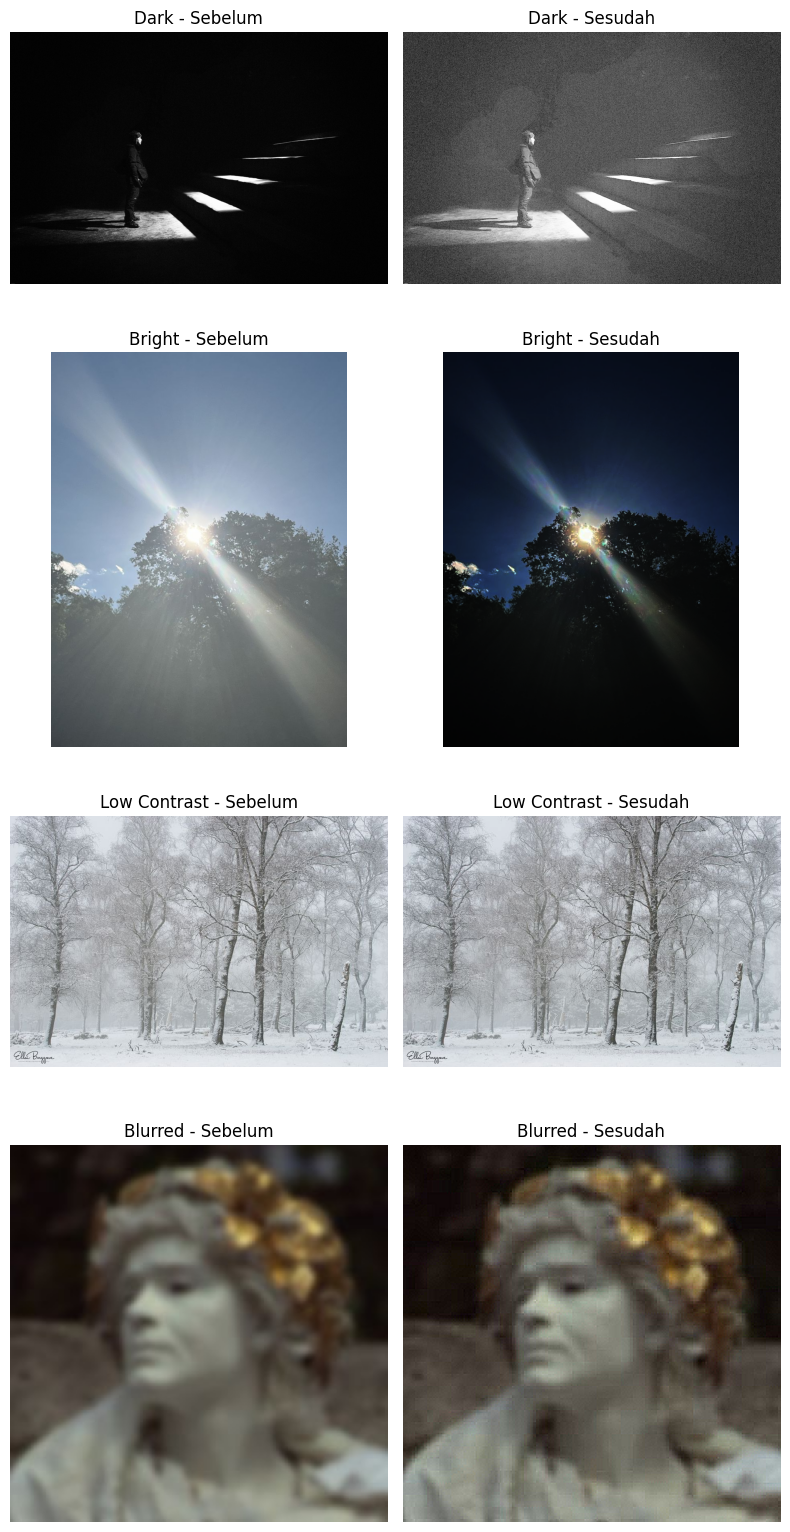

In [32]:
pasangan = [
    ('Dark', img_dark, hasil_dark),
    ('Bright', img_bright, hasil_bright),
    ('Low Contrast', img_contrast, hasil_contrast),
    ('Blurred', img_blur, hasil_blur),
]

fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for i, (nama, sebelum, sesudah) in enumerate(pasangan):
    axes[i, 0].imshow(sebelum)
    axes[i, 0].set_title(f'{nama} - Sebelum')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(sesudah)
    axes[i, 1].set_title(f'{nama} - Sesudah')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()